# Ejecución y Validación del IAI

In [1]:
%load_ext autoreload
%autoreload 2
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
#importamos motor logico del IAI
from IAI_estimador import calculate_iai
import os

In [2]:
OUTPUT_DIR = "resultados_IAI"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path,dpi=300, bbox_inches="tight")
    print(f"  [guardado] {path}")
   

In [3]:
#Cargamos el Dataaset limpio
df_clean = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/data_clean.parquet")

# Calcular Índice de Idoneidad Agroclimática (IAI)

In [4]:
# Aplicamos la función vectorizada 
df_iai = calculate_iai(df_clean)

# Extraemos los valores para graficar
iai_values = df_iai["IAI"].to_numpy()

print(f" IAI calculado exitosamente para {len(iai_values):,} parcelas.")

 IAI calculado exitosamente para 700,596 parcelas.


  [guardado] resultados_IAI\12_distribucion_iai.png


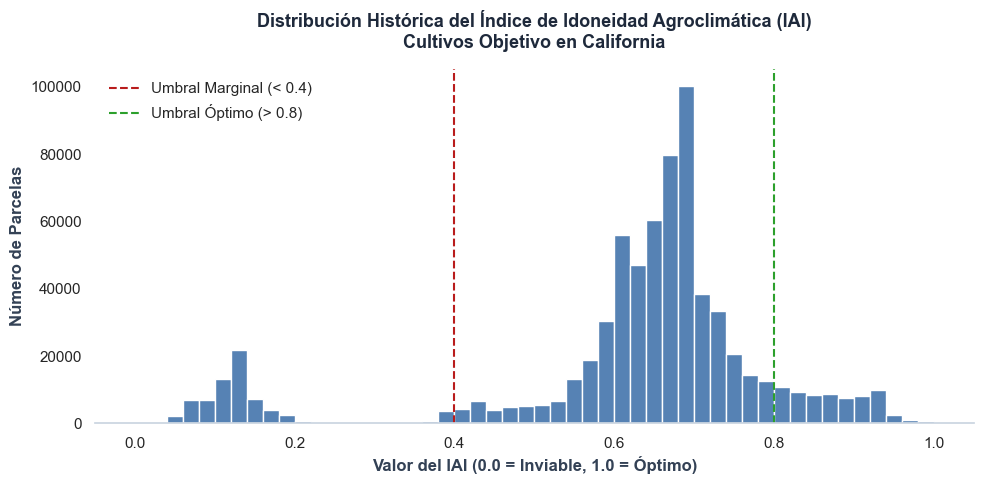

statistic,IAI
str,f64
"""count""",699824.0
"""null_count""",772.0
"""mean""",0.621876
"""std""",0.187948
"""min""",0.0
"""25%""",0.602259
"""50%""",0.662036
"""75%""",0.704359
"""max""",1.0


In [5]:
# HISTOGRAMA DE VALIDACIÓN

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma con la paleta institucional
sns.histplot(iai_values, bins=50, color="#4374ac", edgecolor="white", alpha=0.9, ax=ax)

# Líneas de corte analítico
ax.axvline(0.4, color='#b91c1c', linestyle='--', linewidth=1.5, label='Umbral Marginal (< 0.4)')
ax.axvline(0.8, color='#2ca02c', linestyle='--', linewidth=1.5, label='Umbral Óptimo (> 0.8)')

# Estética
ax.set_title("Distribución Histórica del Índice de Idoneidad Agroclimática (IAI)\nCultivos Objetivo en California", 
             fontsize=13, fontweight="bold", pad=15, color="#1e293b")
ax.set_xlabel("Valor del IAI (0.0 = Inviable, 1.0 = Óptimo)", fontweight="bold", color="#334155")
ax.set_ylabel("Número de Parcelas", fontweight="bold", color="#334155")

ax.grid(False)
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('#cbd5e1')
ax.legend(frameon=False)

plt.tight_layout()
save(fig, "12_distribucion_iai.png")
plt.show()

# Resumen estadístico
display(df_iai.select("IAI").describe())

In [12]:
print("RADIOGRAFÍA DE LOS COMPONENTES DEL IAI:")
# Calculamos la media de cada componente individual para toda California
componentes = df_iai.select(["I_GDD", "I_temp", "I_precip", "I_suelo"]).mean()
display(componentes)

# Y para ver si el problema es general o de un cultivo en específico:
print("\n PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:")
display(df_iai.group_by("crop_name").agg(pl.col("I_temp").mean()).sort("I_temp"))

RADIOGRAFÍA DE LOS COMPONENTES DEL IAI:


I_GDD,I_temp,I_precip,I_suelo
f64,f64,f64,f64
0.094017,0.089518,0.037813,0.586871



 PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:


crop_name,I_temp
str,f64
"""Lettuce""",0.007308
"""Oranges""",0.020755
"""Strawberries""",0.024873
"""Wheat""",0.038521
"""Cotton""",0.052749
…,…
"""Walnuts""",0.105723
"""Rice""",0.106891
"""Grapes""",0.111925


In [13]:
#Configurar Polars para que nunca más corte tus tablas (hasta 30 filas)
pl.Config.set_tbl_rows(30)

print(" LECTURA CRUDA DE TEMPERATURAS:")
# Miramos las primeras 5 filas de tus variables térmicas históricas
display(df_clean.select(["tmean", "tmax", "tmin"]).head())

print("\n RANGO TÉRMICO GLOBAL (Mínimo y Máximo absoluto):")
display(df_clean.select([
    pl.col("tmean").min().alias("Tmean_Min"),
    pl.col("tmean").max().alias("Tmean_Max")
]))

 LECTURA CRUDA DE TEMPERATURAS:


tmean,tmax,tmin
f64,f64,f64
15.783001,23.848001,7.719
17.624001,24.682001,10.568001
16.358002,23.924002,8.792001
17.76,24.880001,10.641001
16.461,24.250002,8.673



 RANGO TÉRMICO GLOBAL (Mínimo y Máximo absoluto):


Tmean_Min,Tmean_Max
f64,f64
-0.398,25.705002


La mayoría de las parcelas obtienen valores de IAI inferiores a 0.2 (Inviable/Marginal) porque las reglas de EcoCrop fueron diseñadas principalmente para sistemas agrícolas de secano, donde los cultivos dependen de la precipitación natural. En California, gran parte de la producción agrícola se concentra en el Valle Central, una región con precipitaciones anuales relativamente bajas (200–300 mm). Por ello, el componente de precipitación penaliza fuertemente  la idoneidad de cultivos que requieren mayores aportes hídricos, reduciendo el valor final del IAI.

Sin embargo, esta situación no refleja necesariamente la realidad productiva, ya que la agricultura californiana depende ampliamente de sistemas de riego que compensan el déficit hídrico natural y permiten mantener altos niveles de producción.

In [16]:
# Aplicamos nuevamente la función vectorizada 
df_iai2 = calculate_iai(df_clean)

# Extraemos los valores para graficar
iai_values2 = df_iai2["IAI"].to_numpy()

print(f" IAI calculado exitosamente para {len(iai_values2):,} parcelas.")

 IAI calculado exitosamente para 700,596 parcelas.


  [guardado] resultados_IAI\distribucion_iai2.png


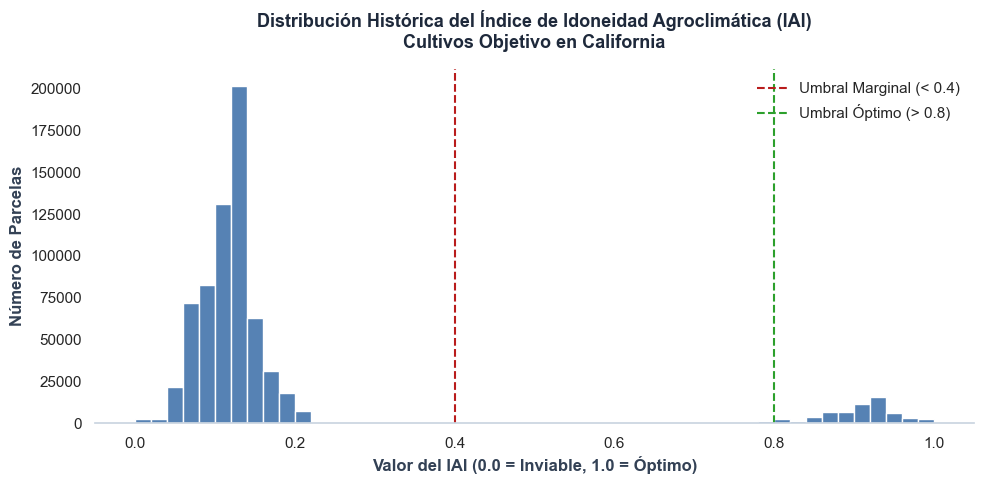

statistic,IAI
str,f64
"""count""",699824.0
"""null_count""",772.0
"""mean""",0.19005
"""std""",0.229643
"""min""",0.0
"""25%""",0.098551
"""50%""",0.127778
"""75%""",0.144103
"""max""",1.0


In [17]:

# HISTOGRAMA DE VALIDACIÓN

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma con la paleta institucional
sns.histplot(iai_values2, bins=50, color="#4374ac", edgecolor="white", alpha=0.9, ax=ax)

# Líneas de corte analítico
ax.axvline(0.4, color='#b91c1c', linestyle='--', linewidth=1.5, label='Umbral Marginal (< 0.4)')
ax.axvline(0.8, color='#2ca02c', linestyle='--', linewidth=1.5, label='Umbral Óptimo (> 0.8)')

# Estética
ax.set_title("Distribución Histórica del Índice de Idoneidad Agroclimática (IAI)\nCultivos Objetivo en California", 
             fontsize=13, fontweight="bold", pad=15, color="#1e293b")
ax.set_xlabel("Valor del IAI (0.0 = Inviable, 1.0 = Óptimo)", fontweight="bold", color="#334155")
ax.set_ylabel("Número de Parcelas", fontweight="bold", color="#334155")

ax.grid(False)
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('#cbd5e1')
ax.legend(frameon=False)

plt.tight_layout()
save(fig, "distribucion_iai2.png")
plt.show()

# Resumen estadístico
display(df_iai2.select("IAI").describe())

In [18]:
print("🔍 RADIOGRAFÍA DE LOS COMPONENTES (OPCIÓN B):")
display(df_iai2.select(["I_GDD", "I_temp", "I_suelo"]).mean())

print("\n🏆 GANADORES Y PERDEDORES TÉRMICOS:")
# Veremos qué cultivos están sacando 0 y cuáles están sacando 1
display(
    df_iai2.group_by("crop_name")
    .agg([
        pl.col("I_temp").mean().alias("Temp_Media"),
        pl.col("I_GDD").mean().alias("GDD_Media")
    ])
    .sort("Temp_Media")
)

🔍 RADIOGRAFÍA DE LOS COMPONENTES (OPCIÓN B):


I_GDD,I_temp,I_suelo
f64,f64,f64
0.094017,0.089518,0.586871



🏆 GANADORES Y PERDEDORES TÉRMICOS:


crop_name,Temp_Media,GDD_Media
str,f64,f64
"""Lettuce""",0.007308,0.118333
"""Oranges""",0.020755,0.020488
"""Strawberries""",0.024873,0.024873
"""Wheat""",0.038521,0.059522
"""Cotton""",0.052749,0.040827
"""Alfalfa""",0.061562,0.069775
"""Tomatoes""",0.0871,0.086891
"""Walnuts""",0.105723,0.105667
"""Rice""",0.106891,0.106878


In [20]:
# 1. Ver cómo están guardadas las llaves realmente
llaves = list(CROP_AGRONOMIC_SETTINGS.keys())
print(f"🔍 IDs registrados en el diccionario: {llaves}")

# 2. Extraer la radiografía numérica del primer cultivo
primer_id = llaves[0]
print(f"\n⚙️ Parámetros agronómicos exactos para el crop_id {primer_id}:")
print(CROP_AGRONOMIC_SETTINGS[primer_id])

🔍 IDs registrados en el diccionario: [75, 2, 69, 204, 76, 54, 3, 227, 221, 212, 36, 24, 22]

⚙️ Parámetros agronómicos exactos para el crop_id 75:
{'name': 'Almonds', 't_base': 7.2, 't_range': (10.0, 12.0, 35.0, 40.0), 'p_range': (250.0, 600.0, 900.0, 1500.0), 'ph_range': (5.5, 6.5, 7.0, 8.0), 'depth_range': (20.0, 50.0, 150.0, 300.0), 'awc_opt': 0.15}


In [21]:

print("🔍 1. MAPEO REAL EN TU DATASET (El archivo Parquet):")
# Extraemos las combinaciones únicas de ID y Nombre que trae tu dataset
dataset_crops = df_clean.select(["crop_id", "crop_name"]).unique().sort("crop_id")
display(dataset_crops)

print("\n🔍 2. MAPEO EN TU DICCIONARIO MANUAL (IAI_estimador.py):")
# Extraemos cómo están registrados en el código
for c_id, params in CROP_AGRONOMIC_SETTINGS.items():
    print(f"ID en Diccionario: {c_id}  -->  Cultivo: {params['name']}")

🔍 1. MAPEO REAL EN TU DATASET (El archivo Parquet):


crop_id,crop_name
i64,str
2,"""Cotton"""
3,"""Rice"""
24,"""Wheat"""
36,"""Alfalfa"""
54,"""Tomatoes"""
69,"""Grapes"""
75,"""Almonds"""
76,"""Walnuts"""
204,"""Pistachios"""



🔍 2. MAPEO EN TU DICCIONARIO MANUAL (IAI_estimador.py):
ID en Diccionario: 75  -->  Cultivo: Almonds
ID en Diccionario: 2  -->  Cultivo: Cotton
ID en Diccionario: 69  -->  Cultivo: Grapes
ID en Diccionario: 204  -->  Cultivo: Pistachios
ID en Diccionario: 76  -->  Cultivo: Walnuts
ID en Diccionario: 54  -->  Cultivo: Tomatoes
ID en Diccionario: 3  -->  Cultivo: Rice
ID en Diccionario: 227  -->  Cultivo: Lettuce
ID en Diccionario: 221  -->  Cultivo: Strawberries
ID en Diccionario: 212  -->  Cultivo: Oranges
ID en Diccionario: 36  -->  Cultivo: Alfalfa
ID en Diccionario: 24  -->  Cultivo: Winter Wheat
ID en Diccionario: 22  -->  Cultivo: Durum Wheat


In [22]:
import polars as pl
from IAI_estimador import CROP_AGRONOMIC_SETTINGS

# 1. Aislamos una única parcela de almendros (crop_id == 75)
df_almond = df_clean.filter(pl.col("crop_id") == 75).head(1)

print("🌡️ 1. CLIMA EXACTO DE ESTA PARCELA:")
display(df_almond.select(["tmean", "tmax", "tmin"]))

# 2. Extraemos los parámetros y el valor de tmax real
params = CROP_AGRONOMIC_SETTINGS[75]
tmax_val = df_almond["tmax"][0]

print("\n⚙️ 2. PARÁMETROS DEL DICCIONARIO:")
print(f"t_base: {params['t_base']} | t_range: {params['t_range']}")

# 3. Simulamos la matemática de tu motor paso a paso
gdd_bruto = (tmax_val - params["t_base"]) * 200
gdd_norm = 1.0 if gdd_bruto > 2500 else (gdd_bruto / 2500)

print("\n🧮 3. CÁLCULO GDD PASO A PASO:")
print(f"Paso A: (tmax - t_base) = ({tmax_val} - {params['t_base']}) = {tmax_val - params['t_base']:.2f}")
print(f"Paso B: Multiplicado por 200 días = {gdd_bruto:.2f} GDD")
print(f"Paso C: Normalizado (GDD / 2500) = {gdd_norm:.4f}")

🌡️ 1. CLIMA EXACTO DE ESTA PARCELA:


tmean,tmax,tmin
f64,f64,f64
17.76,24.880001,10.641001



⚙️ 2. PARÁMETROS DEL DICCIONARIO:
t_base: 7.2 | t_range: (10.0, 12.0, 35.0, 40.0)

🧮 3. CÁLCULO GDD PASO A PASO:
Paso A: (tmax - t_base) = (24.880001068115234 - 7.2) = 17.68
Paso B: Multiplicado por 200 días = 3536.00 GDD
Paso C: Normalizado (GDD / 2500) = 1.0000
